In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/nifty_500_quarterly_results.csv')

# Clean numeric columns
cols = ['revenue','operating_expenses','operating_profit',
        'net_profit','profit_before_tax']
for col in cols:
    df[col] = df[col].astype(str).str.replace(',','').astype(float)

# Clean margin column
df['operating_profit_margin'] = df['operating_profit_margin'].astype(str).str.replace('%','').astype(float)

print(df.shape)
df.head()

(501, 17)


,name,NSE_code,BSE_code,sector,industry,revenue,operating_expenses,operating_profit,operating_profit_margin,depreciation,interest,profit_before_tax,tax,net_profit,EPS,profit_TTM,EPS_TTM
0,3M India Ltd.,3MINDIA,523395,GENERAL INDUSTRIALS,INDUSTRIAL MACHINERY,1057.0,847.4,192.1,18.48,12.9,0.7,195.9,49.8,146.1,129.7,535.9,475.7
1,ACC Ltd.,ACC,500410,CEMENT AND CONSTRUCTION,CEMENT & CEMENT PRODUCTS,4644.8,3885.4,549.3,12.39,212.8,28.9,517.7,131.5,387.9,20.7,"1,202.7",64.0
2,AIA Engineering Ltd.,AIAENG,532683,GENERAL INDUSTRIALS,OTHER INDUSTRIAL GOODS,1357.1,912.7,382.1,29.51,24.5,7.4,412.5,88.4,323.1,34.3,"1,216.1",128.9
3,APL Apollo Tubes Ltd.,APLAPOLLO,533758,METALS & MINING,IRON & STEEL PRODUCTS,4650.0,4305.4,325.0,7.02,41.3,26.6,276.7,73.8,202.9,7.3,767.5,27.7
4,Au Small Finance Bank Ltd.,AUBANK,540611,BANKING AND FINANCE,BANKS,2956.5,1026.7,647.7,25.59,0,"1,282.1",533.4,131.5,401.8,6.0,"1,606.2",24.0


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df[cols].describe())

Missing values:
 name                       0
NSE_code                   0
BSE_code                   0
sector                     0
industry                   0
revenue                    1
operating_expenses         1
operating_profit           1
operating_profit_margin    1
depreciation               1
interest                   1
profit_before_tax          1
tax                        1
net_profit                 1
EPS                        1
profit_TTM                 3
EPS_TTM                    3
dtype: int64

Basic stats:
              revenue  operating_expenses  operating_profit    net_profit  \
count     500.000000          500.000000        500.000000    500.000000   
mean     7555.894400         5488.167600       1420.109400    671.710400   
std     21979.304032        17742.170047       3779.342474   2059.314601   
min      -167.200000         -180.100000       -508.100000  -8737.900000   
25%       803.725000          546.875000        121.050000     62.350000   
50%   

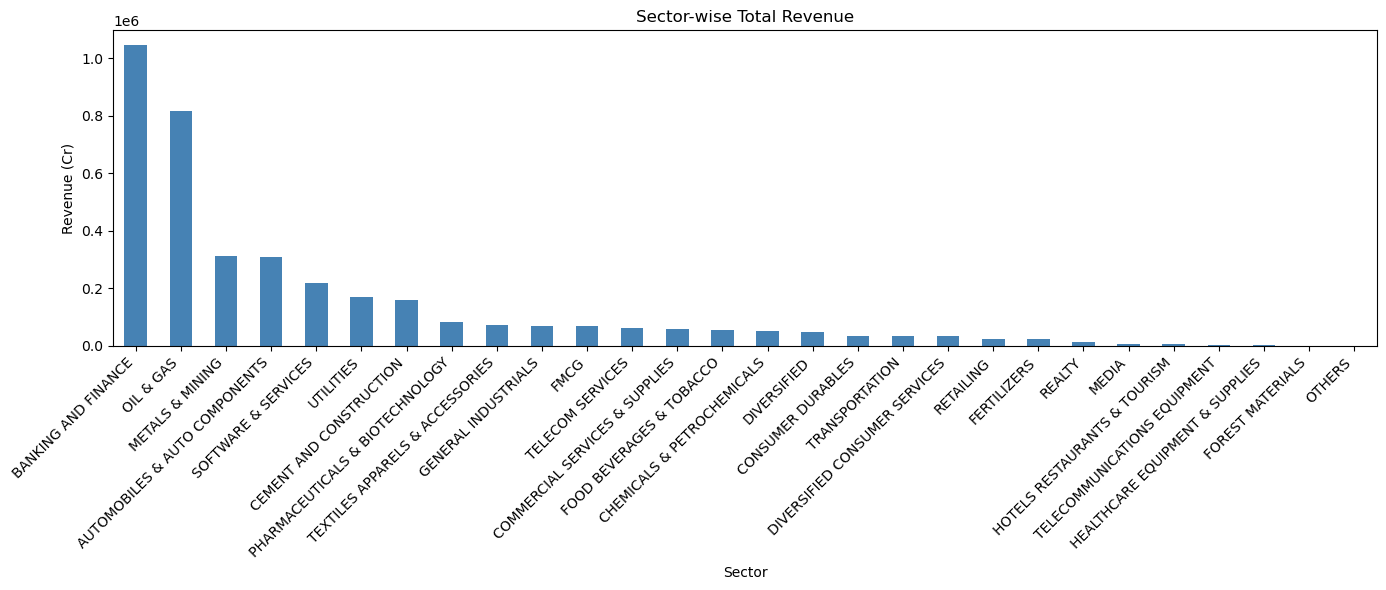

In [3]:
sector_rev = df.groupby('sector')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,6))
sector_rev.plot(kind='bar', color='steelblue')
plt.title('Sector-wise Total Revenue')
plt.xlabel('Sector')
plt.ylabel('Revenue (Cr)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../screenshots/sector_revenue.png')
plt.show()

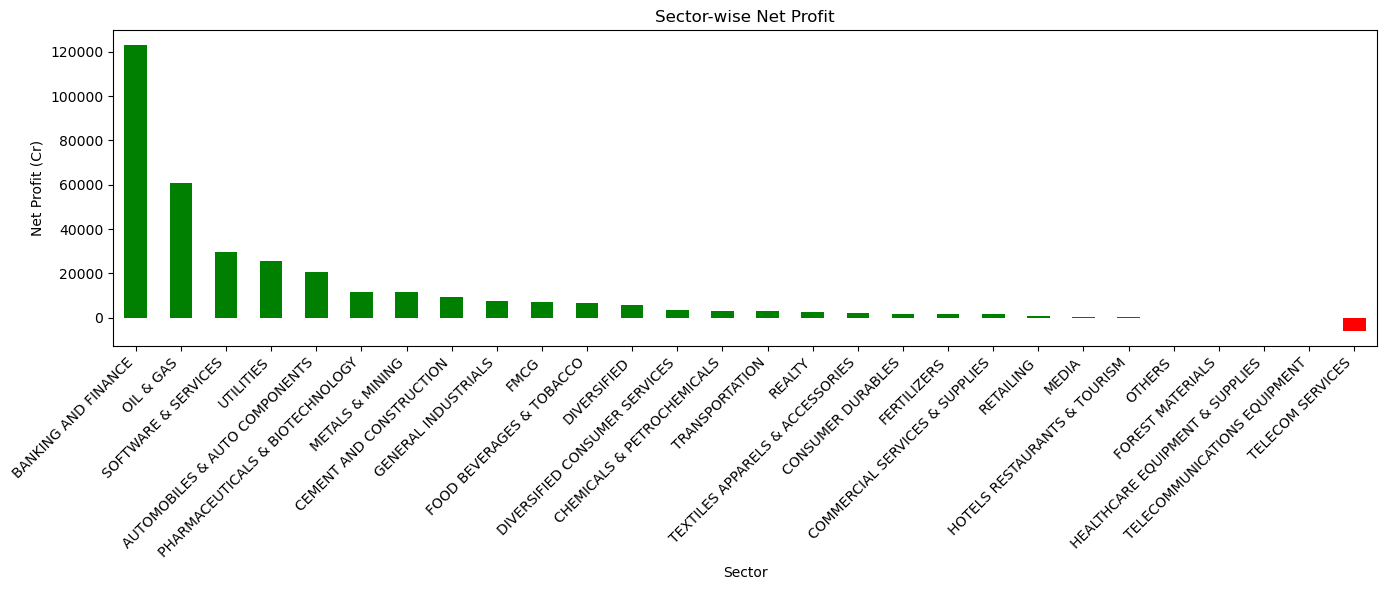

In [4]:
sector_profit = df.groupby('sector')['net_profit'].sum().sort_values(ascending=False)

colors = ['red' if x < 0 else 'green' for x in sector_profit]

plt.figure(figsize=(14,6))
sector_profit.plot(kind='bar', color=colors)
plt.title('Sector-wise Net Profit')
plt.xlabel('Sector')
plt.ylabel('Net Profit (Cr)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../screenshots/sector_profit.png')
plt.show()

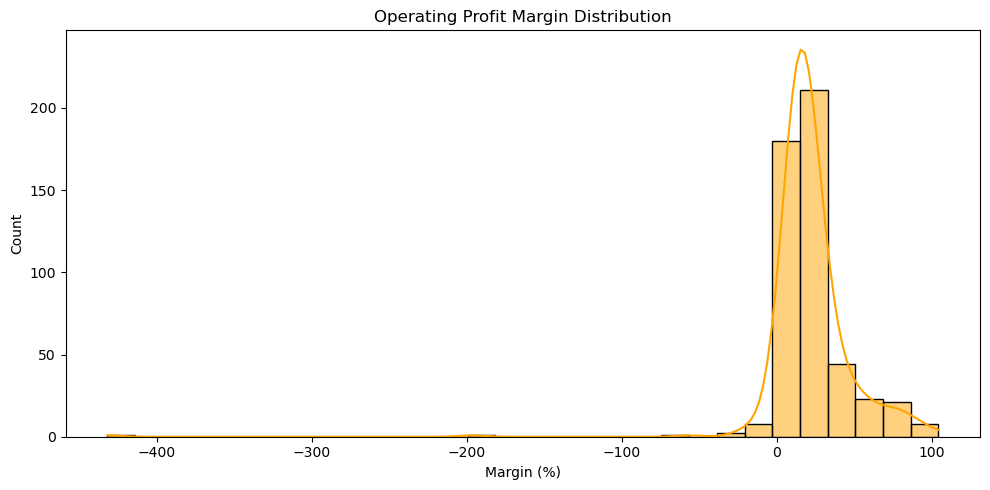

In [5]:
plt.figure(figsize=(10,5))
sns.histplot(df['operating_profit_margin'], bins=30, color='orange', kde=True)
plt.title('Operating Profit Margin Distribution')
plt.xlabel('Margin (%)')
plt.tight_layout()
plt.savefig('../screenshots/margin_distribution.png')
plt.show()

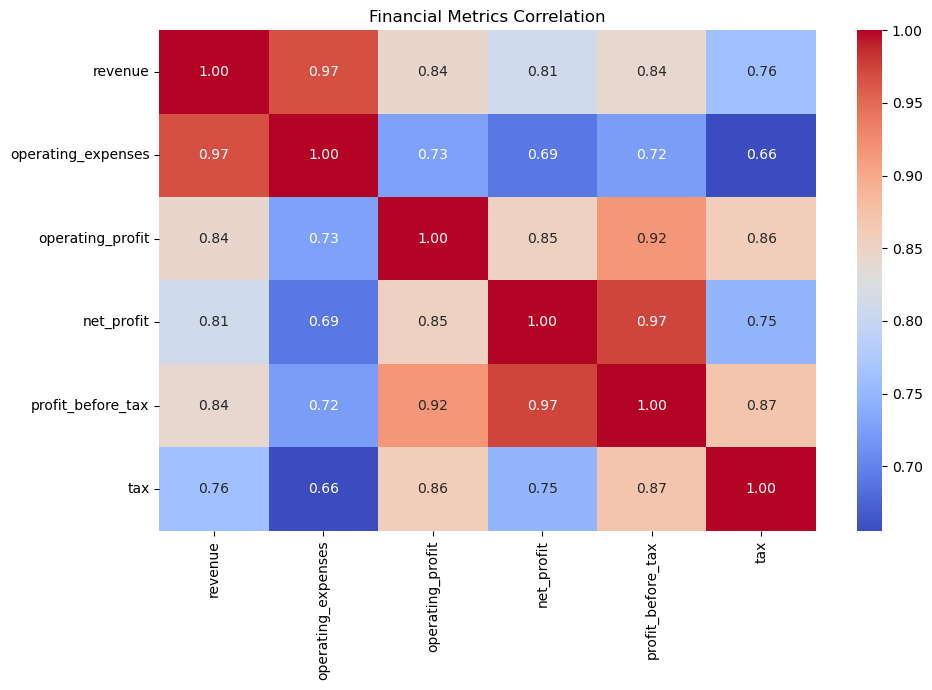

In [8]:
# Clean tax column properly
df['tax'] = df['tax'].astype(str).str.replace(',','').str.strip()
df['tax'] = pd.to_numeric(df['tax'], errors='coerce')

plt.figure(figsize=(10,7))
corr = df[['revenue','operating_expenses','operating_profit',
           'net_profit','profit_before_tax','tax']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Financial Metrics Correlation')
plt.tight_layout()
plt.savefig('../screenshots/correlation.png')
plt.show()

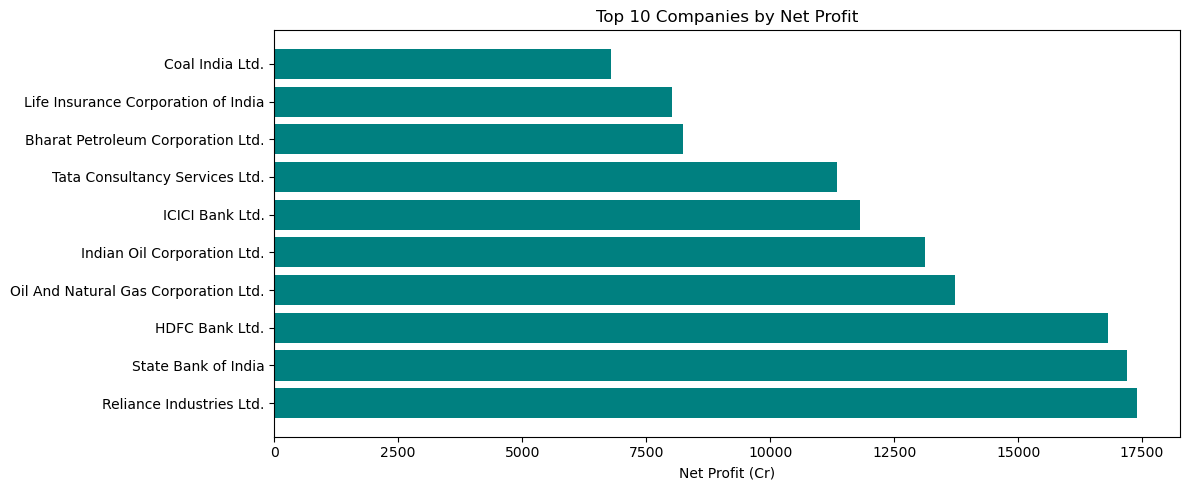

In [9]:
top10 = df.nlargest(10, 'net_profit')[['name','sector','net_profit']]
plt.figure(figsize=(12,5))
plt.barh(top10['name'], top10['net_profit'], color='teal')
plt.title('Top 10 Companies by Net Profit')
plt.xlabel('Net Profit (Cr)')
plt.tight_layout()
plt.savefig('../screenshots/top10_profit.png')
plt.show()

In [10]:
print("=== KEY FINANCIAL INSIGHTS ===")
print(f"Total Companies Analyzed: {len(df)}")
print(f"Total Revenue: ₹{df['revenue'].sum():,.0f} Cr")
print(f"Total Net Profit: ₹{df['net_profit'].sum():,.0f} Cr")
print(f"Avg Profit Margin: {df['operating_profit_margin'].mean():.2f}%")
print(f"Loss-making companies: {(df['net_profit'] < 0).sum()}")
print(f"Most profitable sector: {df.groupby('sector')['net_profit'].sum().idxmax()}")
print(f"Highest margin sector: {df.groupby('sector')['operating_profit_margin'].mean().idxmax()}")

=== KEY FINANCIAL INSIGHTS ===
Total Companies Analyzed: 501
Total Revenue: ₹3,777,947 Cr
Total Net Profit: ₹335,855 Cr
Avg Profit Margin: 21.72%
Loss-making companies: 35
Most profitable sector: BANKING AND FINANCE
Highest margin sector: OTHERS
